# 

In [1]:
%cd ..

/home/lukas/Documents/Uni/Calibration Paper/code2


In [2]:
import glob
import json
import pandas as pd
import re

paths = glob.glob("calibrationData/**/metadata.json", recursive=True)

exclude = ["old", "additional"]

filtered_paths = [path for path in paths if not any(exclude_item in path for exclude_item in exclude)]

rows = []

for path in filtered_paths:
    try:
        with open(path, "r") as f:
            data = json.load(f)
        
        data["folder"] = path.rsplit("/", 1)[0]  # keep folder info
        rows.append(data)
        
    except Exception as e:
        print(f"Error reading {path}: {e}")

df = pd.DataFrame(rows)
df["dataset"] = df["dataset"].fillna("gsm8k")
df["dataset"] = df["dataset"].replace({"cais/mmlu": "mmlu"})


def get_model_size(model_name):
    match = re.search(r"([\d.]+)\s*B", model_name)
    return float(match.group(1)) if match else None

df["model_size"] = df["model"].apply(get_model_size)
    
summary = df.set_index( ["model", "dataset"]).sort_index()

In [3]:
summary

dataset_config  batch_size  thinking        timestamp  \
model           dataset                                                         
Qwen/Qwen3-0.6B ai2_arc  ARC-Challenge          32     False  20260622_173051   
                gsm8k              NaN          48     False  20260630_170343   
                mmlu               NaN          48     False  20260622_152503   
Qwen/Qwen3-1.7B ai2_arc  ARC-Challenge          64     False  20260622_173148   
                gsm8k              NaN          32     False  20260630_170635   
                mmlu               NaN          32     False  20260622_154426   
Qwen/Qwen3-14B  ai2_arc  ARC-Challenge          48     False  20260622_174328   
                gsm8k              NaN          48     False  20260630_173130   
                mmlu               NaN          16     False  20260621_190850   
Qwen/Qwen3-32B  ai2_arc  ARC-Challenge          48     False  20260622_180623   
                gsm8k              NaN          32     False  20260630_173549   
                mmlu               NaN          16     False  20260630_164310   
Qwen/Qwen3-4B   ai2_arc  ARC-Challenge          64     False  20260622_173257   
                gsm8k              NaN          16     False  20260630_171037   
                mmlu               NaN          16     False  20260622_155853   
Qwen/Qwen3-8B   ai2_arc  ARC-Challenge          20     False  20260622_173542   
                gsm8k              NaN          32     False  20260626_152128   
                mmlu               NaN          32     False  20260621_193541   

                        device max_samples  \
model           dataset                      
Qwen/Qwen3-0.6B ai2_arc   cuda        None   
                gsm8k     cuda        None   
                mmlu      cuda        None   
Qwen/Qwen3-1.7B ai2_arc   cuda        None   
                gsm8k     cuda        None   
                mmlu      cuda        None   
Qwen/Qwen3-14B  ai2_arc   cuda        None   
                gsm8k     cuda        None   
                mmlu      cuda        None   
Qwen/Qwen3-32B  ai2_arc   cuda        None   
                gsm8k     cuda        None   
                mmlu      cuda        None   
Qwen/Qwen3-4B   ai2_arc   cuda        None   
                gsm8k     cuda        None   
                mmlu      cuda        None   
Qwen/Qwen3-8B   ai2_arc   cuda        None   
                gsm8k     cuda        None   
                mmlu      cuda        None   

                                                             system_prompt  \
model           dataset                                                      
Qwen/Qwen3-0.6B ai2_arc  Answer the following multiple-choice question....   
                gsm8k    You are a direct mathematical calculator.\n\nI...   
                mmlu      Your task is to answer multiple-choice questi...   
Qwen/Qwen3-1.7B ai2_arc  Answer the following multiple-choice question....   
                gsm8k    You are a direct mathematical calculator.\n\nI...   
                mmlu      Your task is to answer multiple-choice questi...   
Qwen/Qwen3-14B  ai2_arc  Answer the following multiple-choice question....   
                gsm8k    You are a direct mathematical calculator.\n\nI...   
                mmlu      Your task is to answer multiple-choice questi...   
Qwen/Qwen3-32B  ai2_arc  Answer the following multiple-choice question....   
                gsm8k    You are a direct mathematical calculator.\n\nI...   
                mmlu      Your task is to answer multiple-choice questi...   
Qwen/Qwen3-4B   ai2_arc  Answer the following multiple-choice question....   
                gsm8k    You are a direct mathematical calculator.\n\nI...   
                mmlu      Your task is to answer multiple-choice questi...   
Qwen/Qwen3-8B   ai2_arc  Answer the following multiple-choice question....   
                gsm8k    You are a direct mathematical calculator.\n\nI...   


In [4]:
import numpy as np
import re

def preprocess_gsm8k(df):
    df["log_conf"] = df["logprobs"].apply(lambda xs: np.exp(sum(xs)/len(xs)) if xs else 0.5)
    
    
    def extract_answer(text):
        match = re.search(r"####\s*(\-?\d+\.?\d*)", text)
        return float(match.group(1)) if match else None
    
    df["full_answer"] = df["answer"]
    df["answer"] = df["full_answer"].apply(extract_answer)
    
    def parse_prediction(pred):
        match = re.findall(r"-?\d+\.?\d*", str(pred))
        return float(match[-1]) if match else None
    
    df["prediction"] = df["prediction"].apply(parse_prediction)
    df["correct"] = df["answer"] == df["prediction"]

In [5]:
def preprocess_ai2_arc(df):
    df["correct"] = df["answer"] == df["prediction"]
    
    def get_log_conf(row):
        labels = row["labels"]
        probs = row["label_probs"]
        prediction = row["prediction"][0]
    
        try:
            idx = labels.index(prediction)
            return probs[idx]
        except:
            print(labels, probs, prediction)
        
    df["log_conf"] = df.apply(get_log_conf, axis=1)

In [6]:
def preprocess_mmlu(df):
    df["correct"] = df["answer"] == df["prediction"]
    
    def get_log_conf(row):
        labels = row["labels"]
        probs = row["label_probs"]
        prediction = row["prediction"][0]
    
        try:
            idx = labels.index(prediction)
            return probs[idx]
        except:
            print(labels, probs, prediction)
        
    df["log_conf"] = df.apply(get_log_conf, axis=1)

In [7]:
from src import metrics
def process_df(df):
    datasets = df.index.get_level_values("dataset").unique()
    records = []
    for dataset in datasets:
        files = df.xs(dataset, level="dataset")
        
        for model, row in files.iterrows():
            file = row["folder"] + "/outputs.jsonl"
            output_file = pd.read_json(file, lines=True)
            if dataset == "gsm8k":
                preprocess_gsm8k(output_file)
            elif dataset == "ai2_arc":
                preprocess_ai2_arc(output_file)
            elif dataset == "mmlu":
                preprocess_mmlu(output_file)
            else:
                raise ValueError("Unknown Dataset")
            
            rec = {
                "model": model,
                "dataset": dataset,
                "model_size": row["model_size"],
                "acc": output_file["correct"].mean(),
                "num_samples": output_file.shape[0]
            }

            for method in ["verb" , "log"]:
                mask = output_file[f"{method}_conf"].notna()

                y_true = output_file.loc[mask, "correct"]
                y_conf = output_file.loc[mask, f"{method}_conf"]
                
                ece_values = metrics.bootstrap_ece(output_file["correct"], output_file[f"{method}_conf"], n_bootstrap=10)
                
                rec[f"{method}_ece"] = ece_values["ece"]
                rec[f"{method}_ece_se"] = ece_values["se"]
                
                rec[f"{method}_brier"] = metrics.brier_score_loss(y_true, y_conf)
                rec[f"{method}_ap"] = metrics.average_precision_score(y_true, y_conf)
                rec[f"{method}_roc_auc"] = metrics.roc_auc_score(y_true, y_conf)
            
            records.append(rec)
    
    return pd.DataFrame(records)            
            
results = process_df(summary)

['A', 'B', 'C', 'D'] [0.006518247071653001, 0.008369594812393001, 0.017718432471156002, 0.9673936367034911] I


In [8]:
results.head()

,model,dataset,model_size,acc,num_samples,verb_ece,verb_ece_se,verb_brier,verb_ap,verb_roc_auc,log_ece,log_ece_se,log_brier,log_ap,log_roc_auc
0,Qwen/Qwen3-0.6B,ai2_arc,0.6,0.597270,1172,0.388098,0.014764,0.391460,0.607257,0.513541,0.289186,0.012234,0.314029,0.771040,0.688720
1,Qwen/Qwen3-1.7B,ai2_arc,1.7,0.765358,1172,0.181911,0.014577,0.210748,0.780162,0.543928,0.218282,0.014155,0.222278,0.849485,0.687905
2,Qwen/Qwen3-14B,ai2_arc,14.0,0.936007,1172,0.009445,0.005288,0.059066,0.947411,0.590459,0.057835,0.006399,0.058681,0.983166,0.856876
3,Qwen/Qwen3-32B,ai2_arc,32.0,0.951365,1172,0.000145,0.002439,0.045974,0.956819,0.556628,0.037511,0.006421,0.042180,0.988900,0.857202
4,Qwen/Qwen3-4B,ai2_arc,4.0,0.858362,1172,0.091638,0.009803,0.129974,0.858362,0.500000,0.136792,0.010990,0.136848,0.920635,0.730335


In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cmap = sns.color_palette("flare", as_cmap=True)
colors = cmap(np.linspace(0.2, 0.8, 2))
sns.set_theme(style="whitegrid", palette=colors, context="talk")

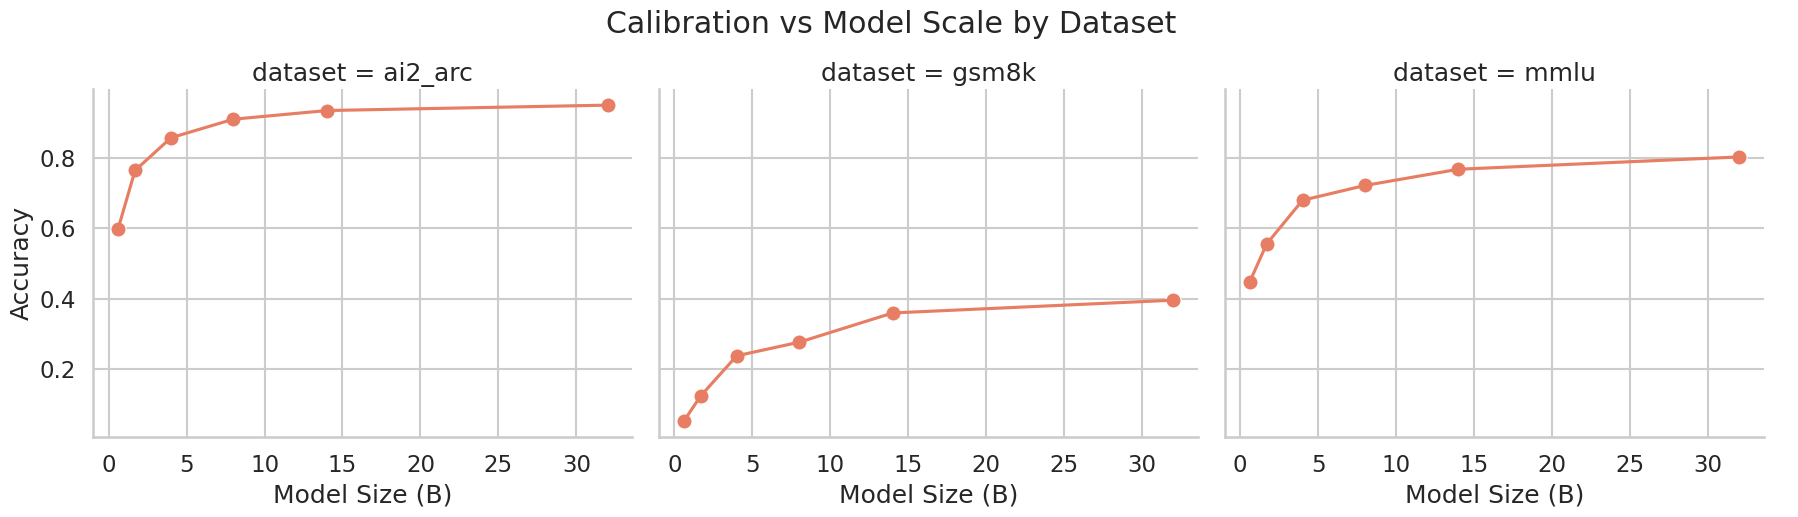

In [10]:
g = sns.FacetGrid(
    results,
    col="dataset",
    height=5,
    aspect=1.2
)

g.map_dataframe(
    sns.scatterplot,
    x="model_size",
    y="acc",
    s=120
)

g.map_dataframe(
    sns.lineplot,
    x="model_size",
    y="acc",
    legend=False
)

g.add_legend()
g.set_axis_labels("Model Size (B)", "Accuracy")
g.fig.suptitle("Calibration vs Model Scale by Dataset", y=1.05)

plt.show()

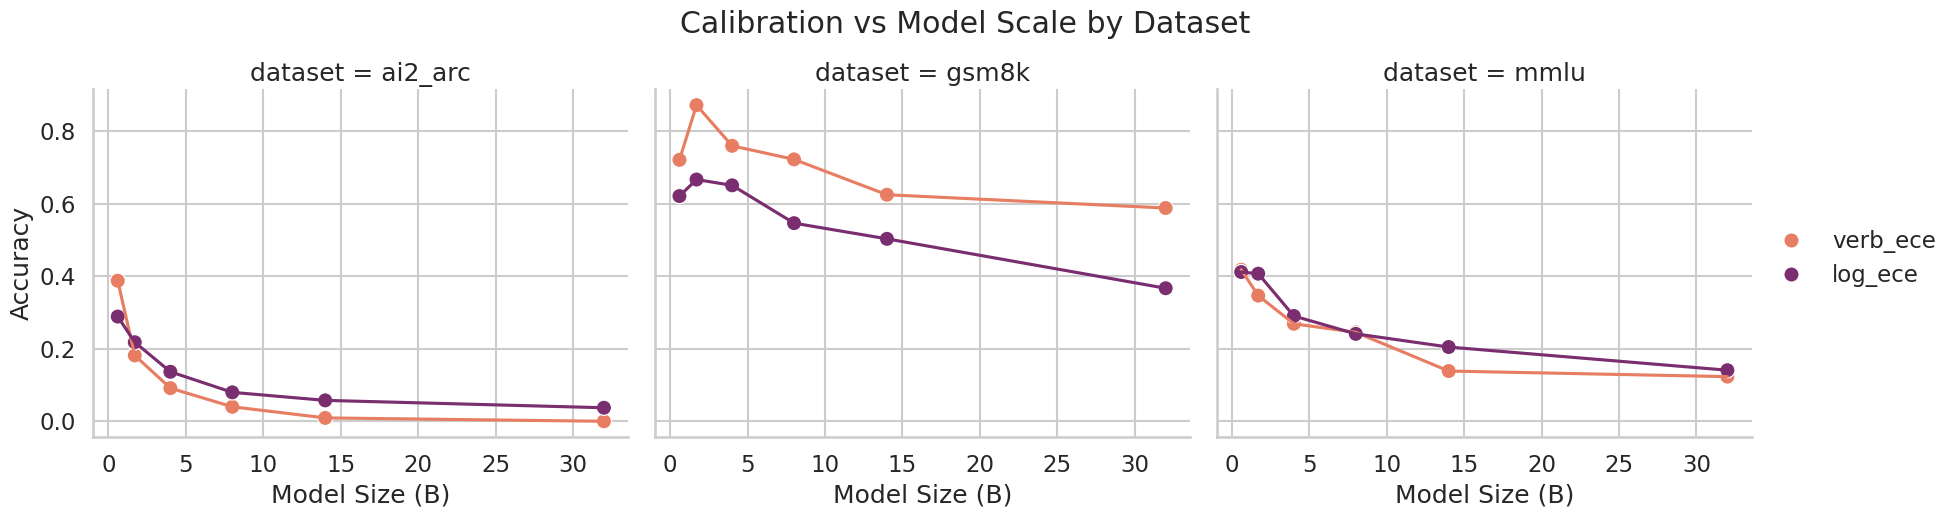

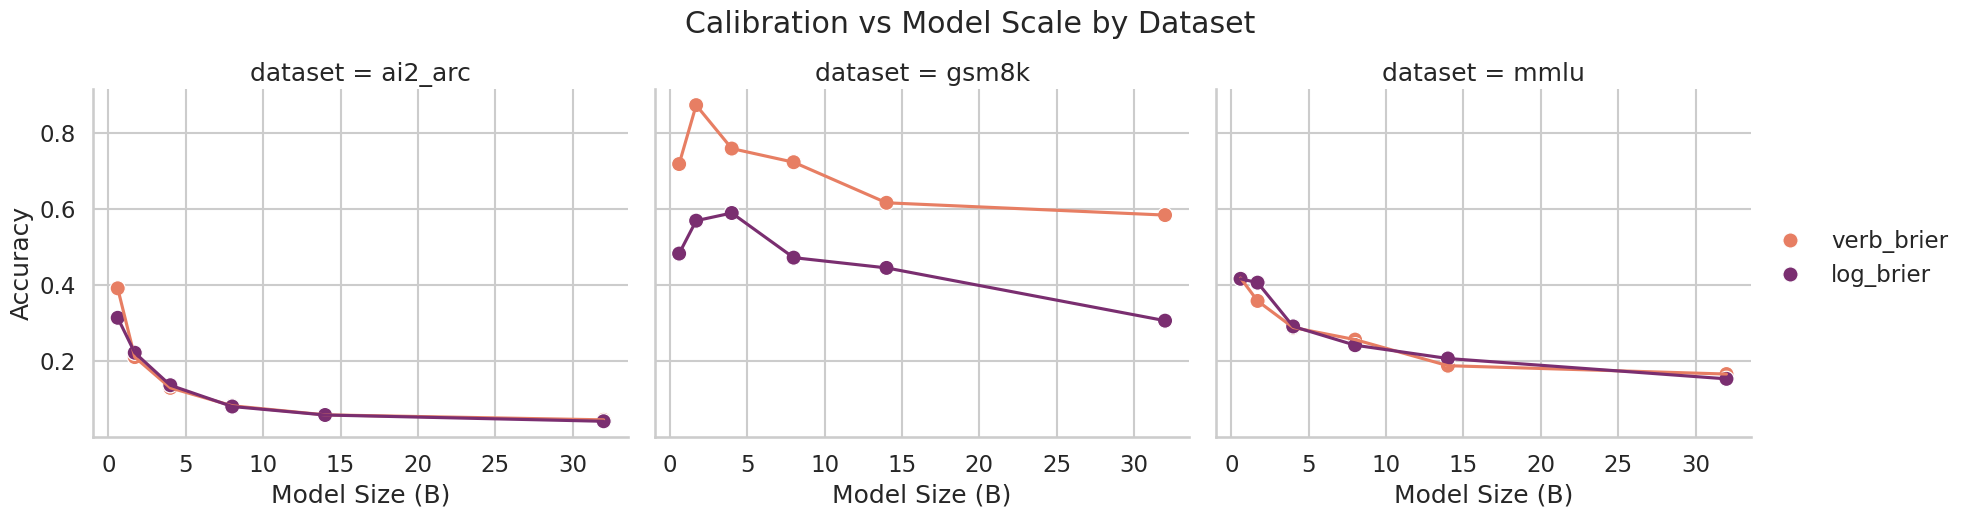

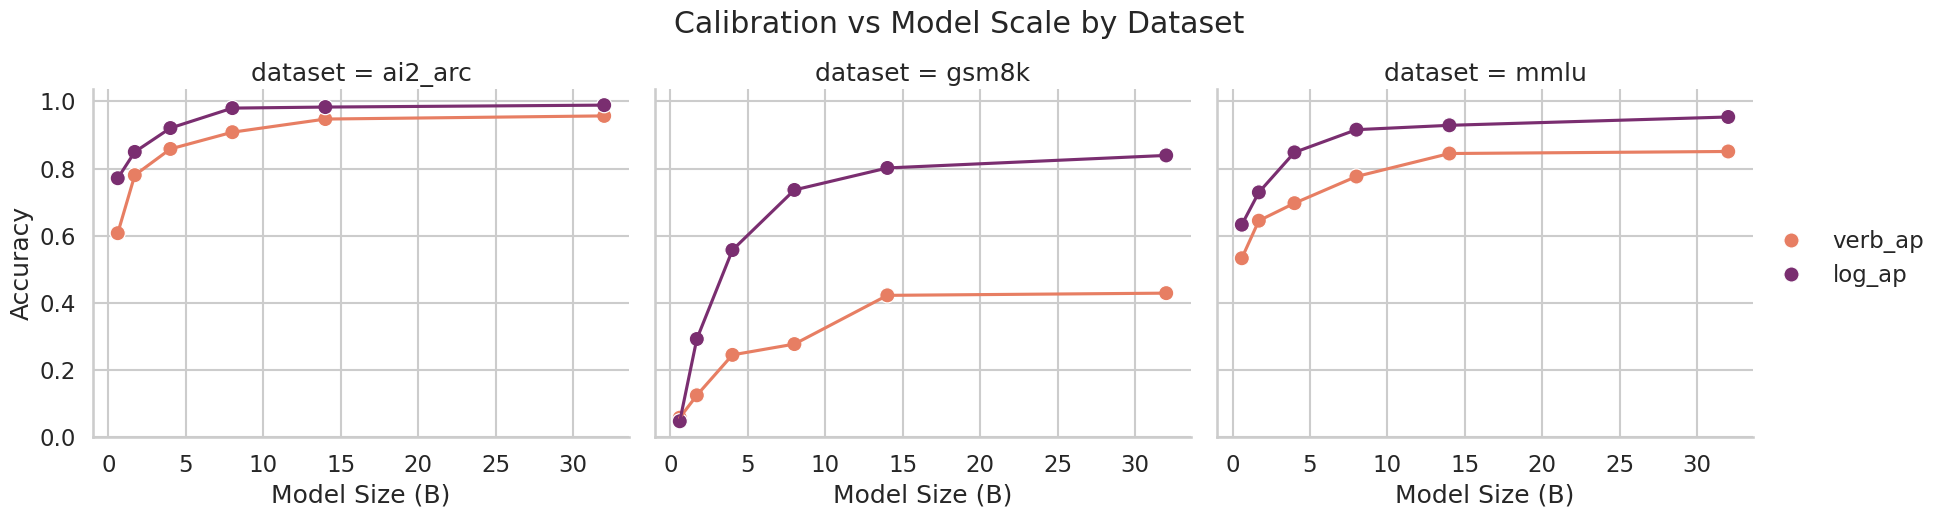

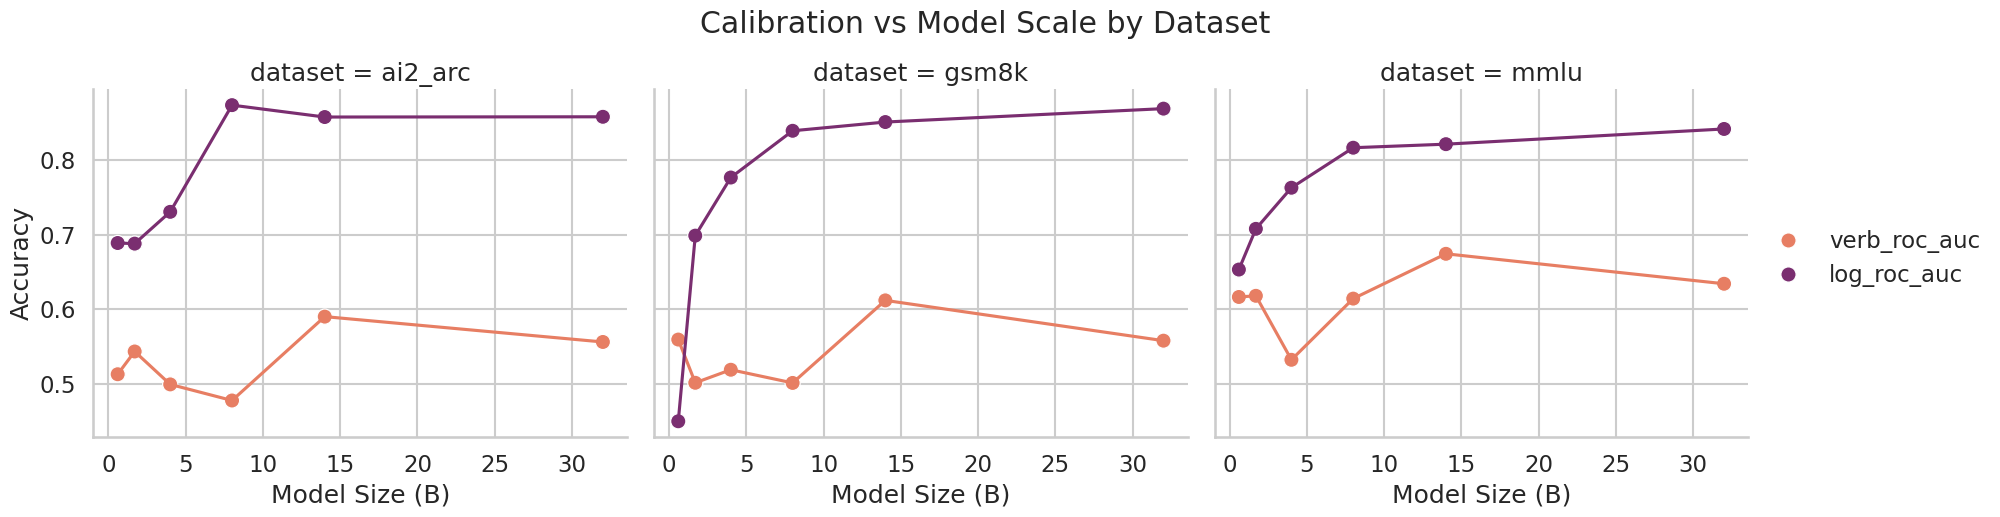

In [11]:
for metric in ["ece", "brier", "ap", "roc_auc"]:
    df_melt = results.melt(
        id_vars=["model_size", "dataset"],
        value_vars=[f"verb_{metric}", f"log_{metric}"],
        var_name="metric",
        value_name=metric
    )
    
    g = sns.FacetGrid(
        df_melt,
        col="dataset",
        height=5,
        aspect=1.2
    )
    
    g.map_dataframe(
        sns.scatterplot,
        x="model_size",
        y=metric,
        hue="metric",
        s=120
    )
    
    g.map_dataframe(
        sns.lineplot,
        x="model_size",
        y=metric,
        hue="metric",
        legend=False
    )
    
    g.add_legend()
    g.set_axis_labels("Model Size (B)", "Accuracy")
    g.fig.suptitle("Calibration vs Model Scale by Dataset", y=1.05)
    
    plt.show()
    g.set_axis_labels("Model Size (B)", metric)
    g.fig.suptitle("Calibration vs Model Scale by Dataset", y=1.05)
    
    plt.show()

In [12]:
df_ece = results.melt(
    id_vars=["model_size", "dataset", "acc"],
    value_vars=["verb_ece", "log_ece"],
    var_name="metric",
    value_name="ece"
)
df_ece

,model_size,dataset,acc,metric,ece
0,0.6,ai2_arc,0.597270,verb_ece,0.388098
1,1.7,ai2_arc,0.765358,verb_ece,0.181911
2,14.0,ai2_arc,0.936007,verb_ece,0.009445
3,32.0,ai2_arc,0.951365,verb_ece,0.000145
4,4.0,ai2_arc,0.858362,verb_ece,0.091638
5,8.0,ai2_arc,0.911263,verb_ece,0.040145
6,0.6,gsm8k,0.050796,verb_ece,0.721629
7,1.7,gsm8k,0.123578,verb_ece,0.872631
8,14.0,gsm8k,0.359363,verb_ece,0.625360
9,32.0,gsm8k,0.395754,verb_ece,0.588711


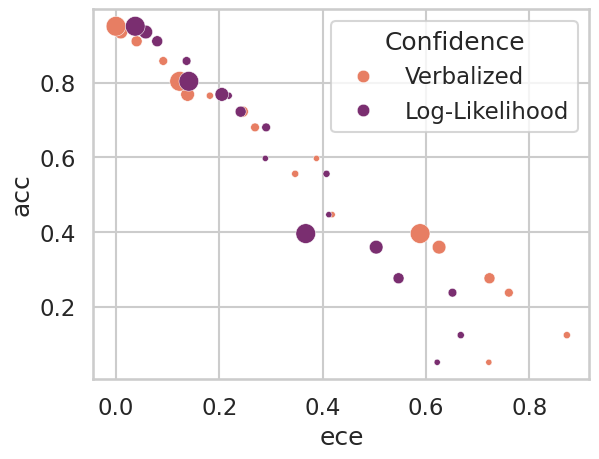

In [24]:
ax = sns.scatterplot(
    data=df_ece,
    x="ece",
    y="acc",
    hue="metric",
    size="model_size",
    sizes=(20, 200),
    legend=True,
)

handles, labels = ax.get_legend_handles_labels()

ax.legend(handles[1:3], ["Verbalized", "Log-Likelihood"], title="Confidence")

In [14]:
df_brier = results.melt(
    id_vars=["model_size", "dataset", "acc"],
    value_vars=["verb_brier", "log_brier"],
    var_name="metric",
    value_name="brier"
)

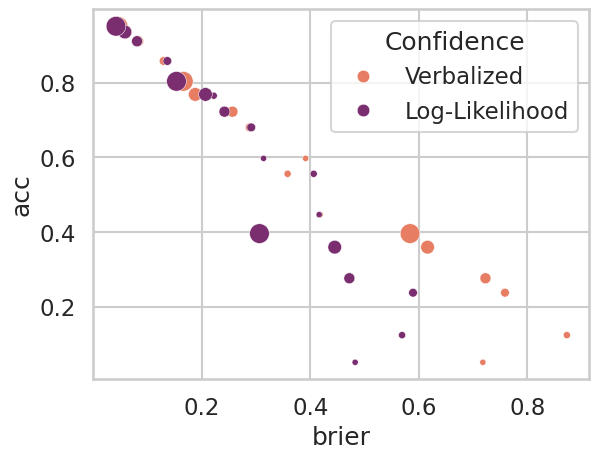

In [25]:
ax = sns.scatterplot(
    data=df_brier,
    x="brier",
    y="acc",
    hue="metric",
    size="model_size",
    sizes=(20, 200),
)

handles, labels = ax.get_legend_handles_labels()

ax.legend(handles[1:3], ["Verbalized", "Log-Likelihood"], title="Confidence")

In [ ]:
df_roc_auc = results.melt(
    id_vars=["model_size", "dataset", "acc"],
    value_vars=["verb_roc_auc", "log_roc_auc"],
    var_name="metric",
    value_name="auc_roc"
)

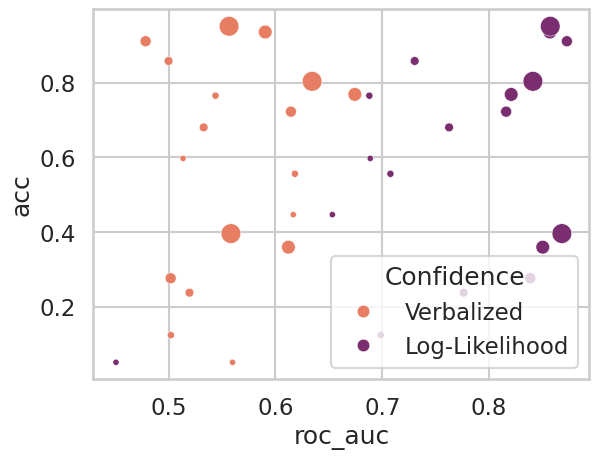

In [ ]:
ax = sns.scatterplot(
    data=df_roc_auc,
    x="roc_auc",
    y="acc",
    hue="metric",
    size="model_size",
    sizes=(20, 200),
)

handles, labels = ax.get_legend_handles_labels()

ax.legend(handles[1:3], ["Verbalized", "Log-Likelihood"], title="Confidence")



In [35]:
df_roc_auc["metric"] = df_roc_auc["metric"].replace(
    {"verb_roc_auc": "Verbalized", "log_roc_auc": "Log-Likelihood"}
)

df_brier["metric"] = df_brier["metric"].replace(
    {"verb_brier": "Verbalized", "log_brier": "Log-Likelihood"}
)   

### join df on model_size, dataset, acc, and metric
df_combined = pd.merge(
    df_roc_auc,
    df_brier,
    on=["model_size", "dataset", "acc", "metric"],
    how="inner"
)

df_combined

,model_size,dataset,acc,metric,roc_auc,brier
0,0.6,ai2_arc,0.597270,Verbalized,0.513541,0.391460
1,1.7,ai2_arc,0.765358,Verbalized,0.543928,0.210748
2,14.0,ai2_arc,0.936007,Verbalized,0.590459,0.059066
3,32.0,ai2_arc,0.951365,Verbalized,0.556628,0.045974
4,4.0,ai2_arc,0.858362,Verbalized,0.500000,0.129974
5,8.0,ai2_arc,0.911263,Verbalized,0.478518,0.082890
6,0.6,gsm8k,0.050796,Verbalized,0.559845,0.717873
7,1.7,gsm8k,0.123578,Verbalized,0.502163,0.872631
8,14.0,gsm8k,0.359363,Verbalized,0.612144,0.616101
9,32.0,gsm8k,0.395754,Verbalized,0.558367,0.583843


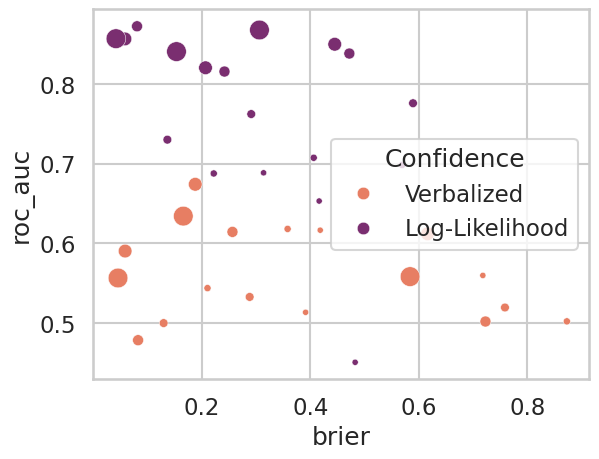

In [37]:
ax = sns.scatterplot(
    data=df_combined,
    x="brier",
    y="roc_auc",
    hue="metric",
    size="model_size",
    sizes=(20, 200),
)

handles, labels = ax.get_legend_handles_labels()

ax.legend(handles[1:3], ["Verbalized", "Log-Likelihood"], title="Confidence")

